In [144]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pltr

In [145]:
torch_workflow = {
    1: "data prep",
    2: "build model",
    3: "train model on train data",
    4: "make predictions and evaluations",
    5: "save and load data",
    6: "put all together"
}

In [146]:
torch_workflow

{1: 'data prep',
 2: 'build model',
 3: 'train model on train data',
 4: 'make predictions and evaluations',
 5: 'save and load data',
 6: 'put all together'}

In [147]:
#new imports
from torch import nn # All pytorch building blocks for nn

torch.__version__

'2.13.0+cu126'

# Data preparation

In [148]:
w = 0.7
b = 0.3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step, device=device).unsqueeze(dim=1)
y = w * X + b

In [149]:
"""Train test split"""
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


In [150]:
def plot_predictions(train_data=X_train.to('cpu'),
                      train_labels=y_train.to('cpu'),
                      test_data=X_test.to('cpu'),
                      test_labels=y_test.to('cpu'),
                      predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # Are there predictions?
    if predictions is not None:
        # Plot the predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

In [151]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, device=device, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, device=device, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

# nn.Module contains all the building blocks for nn
# requires grad means pytorch will track the gradients of this specific parameter for use with torch.autograd and gradient descent
# any submodule of nn.Module needs to override forward() function
# Parameter - what our model should should try and learn, often Pytorch layer from torch.nn sets it for us
# torch.optim - all optimizers that is in pytorch to help optimize gradient descent
# torch.utils.data.Dataset - represents a map between label and feature pairs of data. Such as images and their associated labels
# torch.utils.data.Dataloader - creates a python iterable over a torch Dataset

In [152]:
torch.manual_seed(42)

model_0 = LinearRegression()
list(model_0.parameters())

[Parameter containing:
 tensor([0.1940], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.1391], device='cuda:0', requires_grad=True)]

In [153]:
model_0._parameters

{'weights': Parameter containing:
 tensor([0.1940], device='cuda:0', requires_grad=True),
 'bias': Parameter containing:
 tensor([0.1391], device='cuda:0', requires_grad=True)}

In [154]:
with torch.inference_mode():
    y_pred = model_0(X_test)

y_pred

tensor([[0.2944],
        [0.2982],
        [0.3021],
        [0.3060],
        [0.3099],
        [0.3138],
        [0.3176],
        [0.3215],
        [0.3254],
        [0.3293]], device='cuda:0')

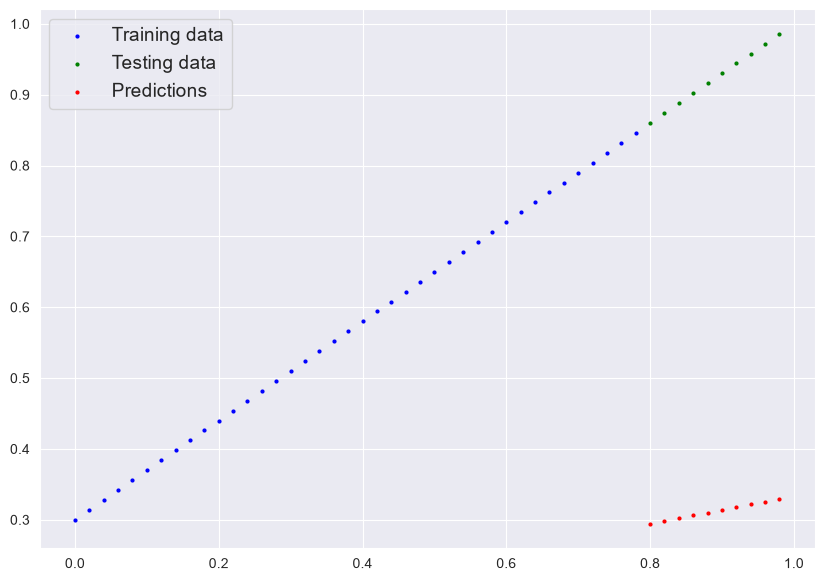

In [155]:
plot_predictions(predictions=y_pred.to('cpu'))

In [156]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.01)

In [157]:
epochs = 301

epoch_count = []
train_loss_values = []
test_loss_values = []

for epoch in range(epochs):
    model_0.train() #swtiches mode to train and sets all parameters to requires_grad=True

    y_pred = model_0(X_train) # goes forward in computational graph
    loss = loss_fn(y_pred, y_train) # compute the difference between y and yhat
    optimizer.zero_grad() #clears previous grads
    loss.backward() #goes back in computational graph computing gradient(derivatives)
    optimizer.step() #performs gradient descent with one step (lr) to get close to actual value

    model_0.eval() #turns of different settings in the model not needed for evaluation/testing (dropout/batch norm layers)
    if epoch % 50 == 0:
        with torch.inference_mode(): #mainly turns off gradient tracking
            y_pred = model_0(X_test)
            loss_pred = loss_fn(y_pred, y_test)

        epoch_count.append(epoch)
        train_loss_values.append(loss.item())
        test_loss_values.append(loss_pred.item())

        print(f"For epoch: {epoch} | Train Loss: {loss} | Test Loss: {loss_pred}")
        print(model_0.state_dict())
        print()


For epoch: 0 | Train Loss: 0.35819512605667114 | Test Loss: 0.5977147221565247
OrderedDict({'weights': tensor([0.1979], device='cuda:0'), 'bias': tensor([0.1491], device='cuda:0')})

For epoch: 50 | Train Loss: 0.06808093190193176 | Test Loss: 0.17172802984714508
OrderedDict({'weights': tensor([0.3619], device='cuda:0'), 'bias': tensor([0.4291], device='cuda:0')})

For epoch: 100 | Train Loss: 0.050219424068927765 | Test Loss: 0.11669877916574478
OrderedDict({'weights': tensor([0.4519], device='cuda:0'), 'bias': tensor([0.4041], device='cuda:0')})

For epoch: 150 | Train Loss: 0.0330439992249012 | Test Loss: 0.0767098143696785
OrderedDict({'weights': tensor([0.5372], device='cuda:0'), 'bias': tensor([0.3681], device='cuda:0')})

For epoch: 200 | Train Loss: 0.015869809314608574 | Test Loss: 0.036034006625413895
OrderedDict({'weights': tensor([0.6228], device='cuda:0'), 'bias': tensor([0.3326], device='cuda:0')})

For epoch: 250 | Train Loss: 0.003948968835175037 | Test Loss: 0.00492193

In [158]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6947], device='cuda:0')),
             ('bias', tensor([0.3096], device='cuda:0'))])

In [159]:
with torch.inference_mode():
    y_pred = model_0(X_test)
    loss = loss_fn(y_pred, y_test)
    print(f"Loss: {loss}")

Loss: 0.004921931307762861


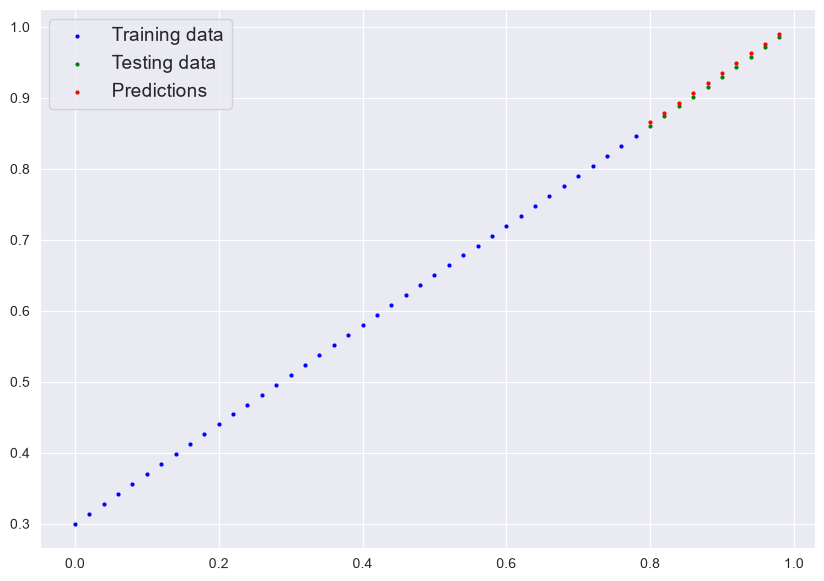

In [160]:
plot_predictions(predictions=y_pred.to('cpu'))

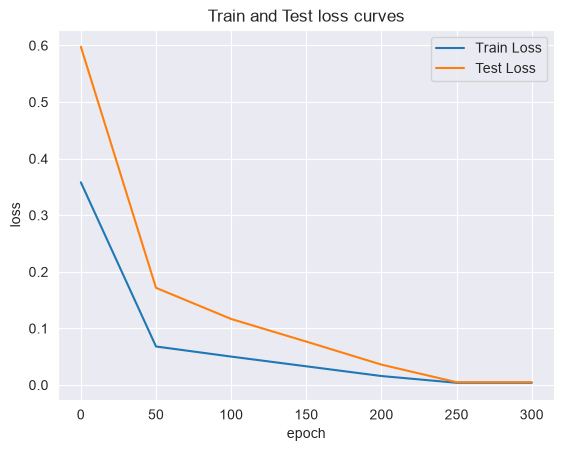

In [161]:
from matplotlib import pyplot as plt

plt.plot(epoch_count, train_loss_values, label='Train Loss')
plt.plot(epoch_count, test_loss_values, label='Test Loss')
plt.title("Train and Test loss curves")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

# Save and Upload model

In [162]:
from pathlib import Path

MODEL_PATH = Path("pytorch_models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(model_0.state_dict(), MODEL_SAVE_PATH)

In [163]:
model_v2_0 = LinearRegression()
model_v2_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

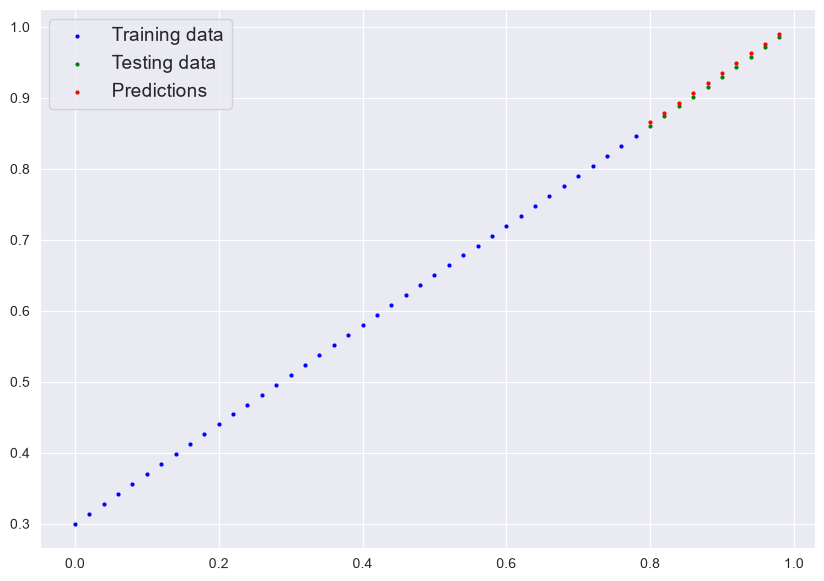

In [164]:
model_v2_0.eval()
with torch.inference_mode():
    preds = model_v2_0(X_test)

plot_predictions(predictions=preds.to('cpu'))